In [12]:
import kagglehub
import os
import ast
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

In [13]:
path = kagglehub.dataset_download("tatheerabbas/psychological-manipulation-conversations-dataset")
file_path = os.path.join(path, "manipulational_conversation.jsonl")

df = pd.read_json(file_path, lines=True)

def get_max_sentiment_message(message_list):
    if not message_list:  #
        return {"text": None, "sentiment_score": None}
    best = max(message_list, key=lambda m: m["sentiment_score"])
    return {
        "text": best["text"],
        "sentiment_score": best["sentiment_score"]
    }

max_message_info = df["messages"].apply(get_max_sentiment_message)

new_df = pd.DataFrame({
    "manipulation_type": df["manipulation_type"],
    "key_message": max_message_info.apply(lambda x: x["text"]),
})

Using Colab cache for faster access to the 'psychological-manipulation-conversations-dataset' dataset.


In [14]:
from openai import OpenAI
import pandas as pd
import time
from sklearn.model_selection import train_test_split

client = OpenAI(api_key="")

LABELS = [
    "charm_flattery",
    "direct_coercion",
    "gaslighting",
    "guilt_tripping",
    "love_bombing",
    "neutral",
    "passive_aggressive"
]

def classify_text_zero_shot(text: str) -> str:
    prompt = f"""
You are classifying a single line of dialogue into exactly one category.

Possible labels:
{", ".join(LABELS)}

Return only the label.

Dialogue: "{text}"
""".strip()

    response = client.responses.create(
        model="gpt-5.4-nano",
        input=prompt
    )

    return response.output_text.strip()


def evaluate_zero_shot(df, split_name):
    predictions = []
    true = []

    for _, row in df.iterrows():
        text = row["key_message"]
        actual = row["manipulation_type"]

        # print(text)
        pred = classify_text_zero_shot(text)
        predictions.append(pred)
        true.append(actual)
        print("pred ", pred)
        print("true ", actual)
        # time.sleep(0.1)

    result_df = df.copy()
    result_df["predicted_label"] = predictions
    result_df["true_label"] = true
    accuracy = (result_df["predicted_label"] == result_df["true_label"]).mean()
    print(f"{split_name} Accuracy: {accuracy:.2%}")
    return result_df, predictions, true


sample_df = new_df.sample(n=min(100, len(new_df)), random_state=42).copy()

validation_df, test_df = train_test_split(
    sample_df,
    test_size=0.5,
    random_state=42,
    stratify=sample_df["manipulation_type"]
)



validation_results, validation_predictions, validation_true = evaluate_zero_shot(validation_df, "Dev")
results, predictions, true = evaluate_zero_shot(test_df, "Test")

val_acc = (
    validation_results["predicted_label"] == validation_results["true_label"]
).mean()

print(f"\nVal Accuracy: {val_acc}")

pred  guilt_tripping
true  guilt_tripping
pred  charm_flattery
true  charm_flattery
pred  neutral
true  neutral
pred  love_bombing
true  love_bombing
pred  guilt_tripping
true  love_bombing
pred  neutral
true  gaslighting
pred  passive_aggressive
true  guilt_tripping
pred  neutral
true  passive_aggressive
pred  neutral
true  direct_coercion
pred  direct_coercion
true  gaslighting
pred  gaslighting
true  gaslighting
pred  direct_coercion
true  direct_coercion
pred  gaslighting
true  gaslighting
pred  gaslighting
true  gaslighting
pred  neutral
true  neutral
pred  neutral
true  direct_coercion
pred  direct_coercion
true  passive_aggressive
pred  neutral
true  neutral
pred  charm_flattery
true  charm_flattery
pred  love_bombing
true  love_bombing
pred  passive_aggressive
true  gaslighting
pred  neutral
true  neutral
pred  love_bombing
true  charm_flattery
pred  direct_coercion
true  direct_coercion
pred  direct_coercion
true  love_bombing
pred  neutral
true  passive_aggressive
pred  love_

Metrics
Macro F1 Score: 0.5635
Weighted F1 Score: 0.5831
Micro F1 Score: 0.6000
Accuracy: 0.6000

📋 PER-CLASS METRICS:
------------------------------------------------------------
 Manipulation Type  Precision   Recall  F1-Score  Support
    charm_flattery   1.000000 0.400000  0.571429        5
   direct_coercion   0.615385 0.800000  0.695652       10
       gaslighting   0.666667 0.571429  0.615385        7
    guilt_tripping   0.714286 0.714286  0.714286        7
      love_bombing   0.600000 0.375000  0.461538        8
           neutral   0.500000 0.875000  0.636364        8
passive_aggressive   0.333333 0.200000  0.250000        5
------------------------------------------------------------

🔍 DETECTABILITY ANALYSIS:
------------------------------------------------------------
Most detectable: guilt_tripping (F1 = 0.7143)
Least detectable: passive_aggressive (F1 = 0.2500)


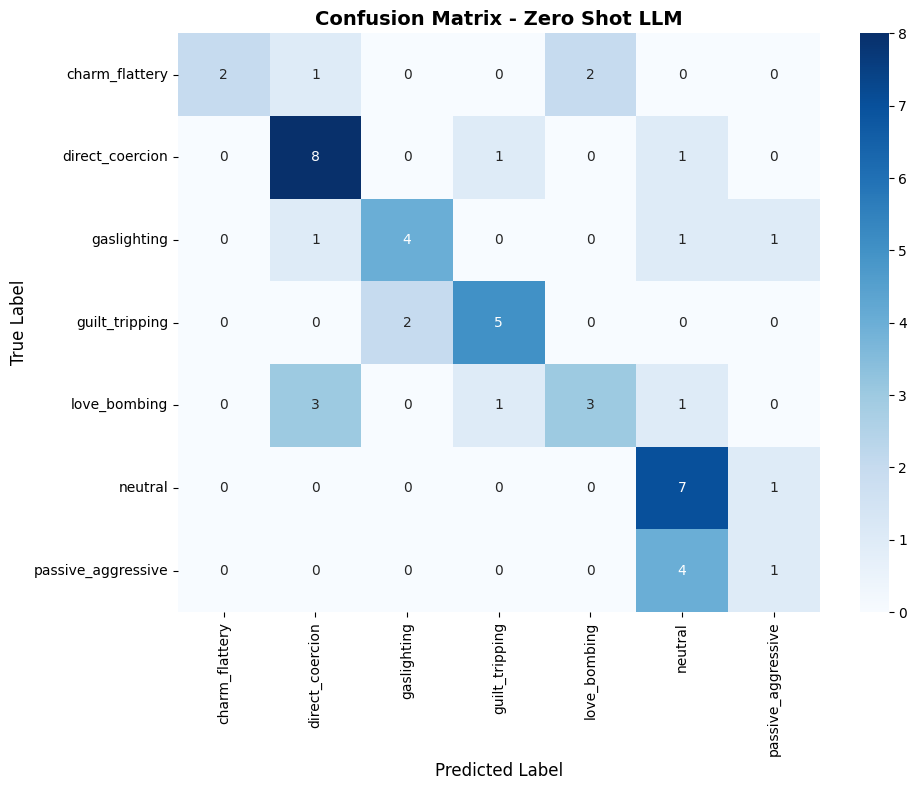

Saved: visualizations/confusion_matrix.png


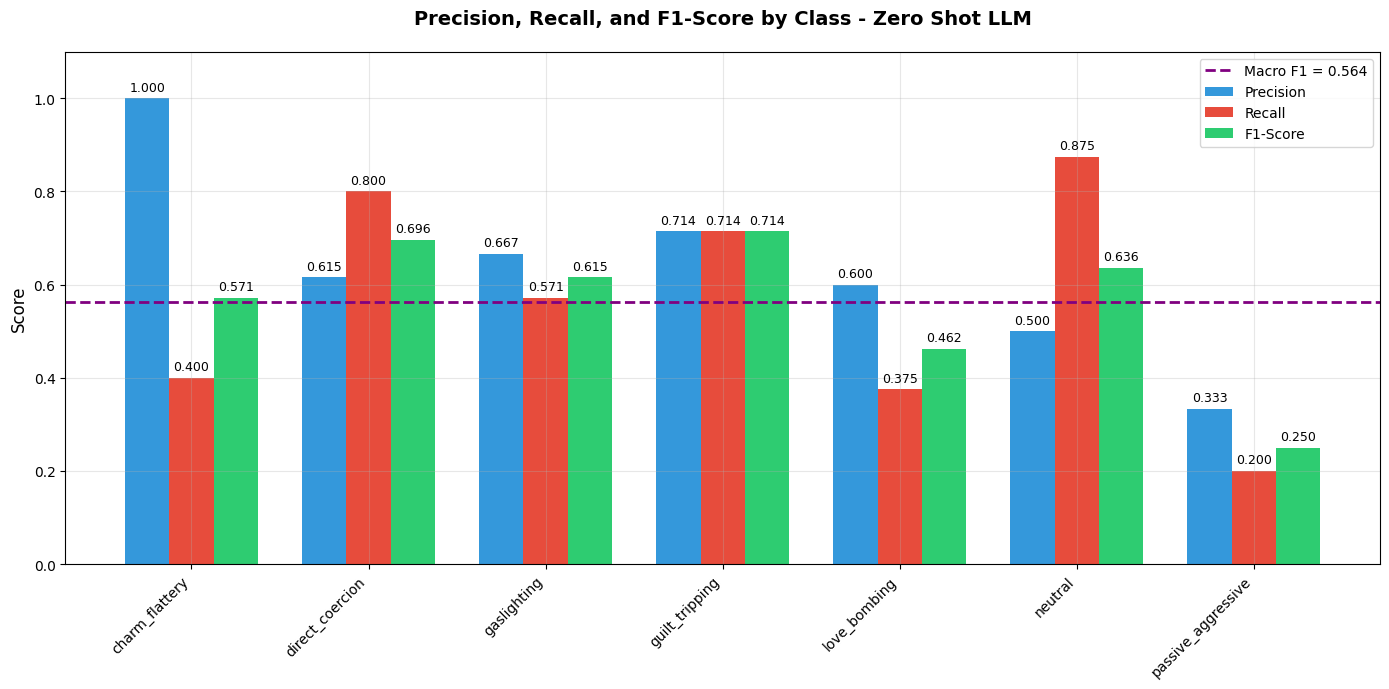

Saved: visualizations/precision_recall_f1.png


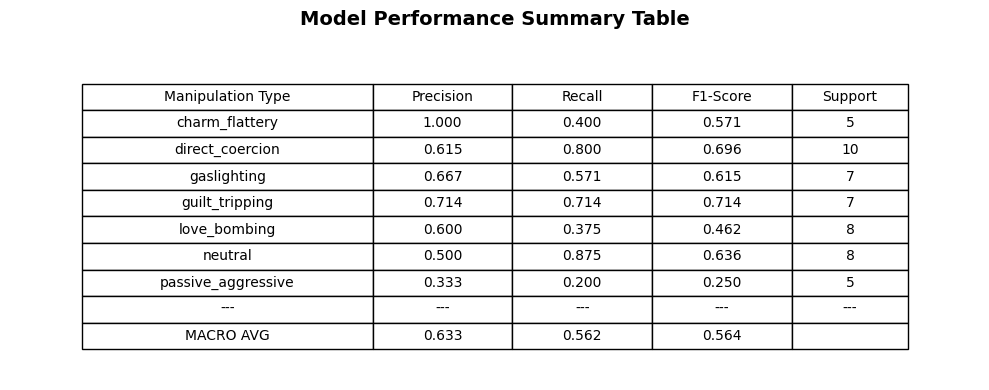

Saved: visualizations/metrics_summary_table.png

📁 ALL VISUALIZATIONS SAVED IN 'visualizations/' FOLDER
Files created:
  1. confusion_matrix.png
  2. precision_recall_f1.png
  3. metrics_summary_table.png

✅ Metrics also saved to 'visualizations/model_performance_metrics.csv'


In [15]:
# Ensure cell 'Bwk179RcYgpl' is run first to define 'predictions' and 'true'
import sklearn
# eval metrics and visualizations
from sklearn.metrics import f1_score, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs('visualizations', exist_ok=True)

y_pred = predictions
y_test = true

# macro f1
macro_f1 = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')
micro_f1 = f1_score(y_test, y_pred, average='micro')

print("="*60)
print("Metrics")
print("="*60)
print(f"Macro F1 Score: {macro_f1:.4f}")
print(f"Weighted F1 Score: {weighted_f1:.4f}")
print(f"Micro F1 Score: {micro_f1:.4f}")
print(f"Accuracy: {sklearn.metrics.accuracy_score(y_test, y_pred):.4f}")
print("="*60)

# per class precision, recall, f1
print("\n📋 PER-CLASS METRICS:")
print("-"*60)
labels = sorted(list(set(y_test)))
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, labels=labels
)

class_metrics = pd.DataFrame({
    'Manipulation Type': labels,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})
print(class_metrics.to_string(index=False))
print("-"*60)

# easiest/hardest to detect classes
print("\n🔍 DETECTABILITY ANALYSIS:")
print("-"*60)
best_class = class_metrics.loc[class_metrics['F1-Score'].idxmax()]
worst_class = class_metrics.loc[class_metrics['F1-Score'].idxmin()]

print(f"Most detectable: {best_class['Manipulation Type']} (F1 = {best_class['F1-Score']:.4f})")
print(f"Least detectable: {worst_class['Manipulation Type']} (F1 = {worst_class['F1-Score']:.4f})")

classes = class_metrics['Manipulation Type']
f1_scores = class_metrics['F1-Score']

# confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels,
            ax=ax)
ax.set_title('Confusion Matrix - Zero Shot LLM', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('visualizations/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: visualizations/confusion_matrix.png")


# precision vs recall vs F1
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(classes))
width = 0.25 # Adjust width to accommodate 3 bars
bars1 = ax.bar(x - width, class_metrics['Precision'], width, label='Precision', color='#3498db')
bars2 = ax.bar(x, class_metrics['Recall'], width, label='Recall', color='#e74c3c')
bars3 = ax.bar(x + width, class_metrics['F1-Score'], width, label='F1-Score', color='#2ecc71')

ax.axhline(y=macro_f1, color='purple', linestyle='--', linewidth=2, label=f'Macro F1 = {macro_f1:.3f}')

ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha='right')
ax.set_title('Precision, Recall, and F1-Score by Class - Zero Shot LLM', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.1) # Increased y-axis limit to prevent label overlap
ax.legend()
ax.grid(True, alpha=0.3)
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('visualizations/precision_recall_f1.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: visualizations/precision_recall_f1.png")


# Metrics summary
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('tight')
ax.axis('off')
table_data = []
for _, row in class_metrics.iterrows():
    table_data.append([row['Manipulation Type'],
                       f"{row['Precision']:.3f}",
                       f"{row['Recall']:.3f}",
                       f"{row['F1-Score']:.3f}",
                       row['Support']])

# Add summary row
table_data.append(['---', '---', '---', '---', '---'])
table_data.append(['MACRO AVG', f"{precision.mean():.3f}", f"{recall.mean():.3f}", f"{macro_f1:.3f}", ''])

column_labels = ['Manipulation Type', 'Precision', 'Recall', 'F1-Score', 'Support']
table = ax.table(cellText=table_data, colLabels=column_labels, cellLoc='center', loc='center',
                  colWidths=[0.25, 0.12, 0.12, 0.12, 0.10])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
ax.set_title('Model Performance Summary Table', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('visualizations/metrics_summary_table.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: visualizations/metrics_summary_table.png")

# summary
print("\n" + "="*60)
print("📁 ALL VISUALIZATIONS SAVED IN 'visualizations/' FOLDER")
print("="*60)
print("Files created:")
print("  1. confusion_matrix.png")
print("  2. precision_recall_f1.png") # Updated filename
print("  3. metrics_summary_table.png")
print("="*60)

# Save metrics to CSV for report
class_metrics.to_csv('visualizations/model_performance_metrics.csv', index=False)
print("\n✅ Metrics also saved to 'visualizations/model_performance_metrics.csv'")